In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler

# 1. Load raw dataset
df = pd.read_csv('data/creditcard.csv')

# 2. Inspect shape & class distribution
print("Dataset Shape:", df.shape)
print("\nClass Distribution:\n", df['Class'].value_counts())

# 3. Scale Time and Amount (handles financial outliers better than standard scaling)
scaler = RobustScaler()
df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['scaled_time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

# Drop original unscaled features
df_cleaned = df.drop(['Time', 'Amount'], axis=1)

# 4. Save preprocessed data
df_cleaned.to_csv('data/creditcard_preprocessed.csv', index=False)
print("\nSaved preprocessed dataset to data/creditcard_preprocessed.csv")

Dataset Shape: (284807, 31)

Class Distribution:
 Class
0    284315
1       492
Name: count, dtype: int64

Saved preprocessed dataset to data/creditcard_preprocessed.csv


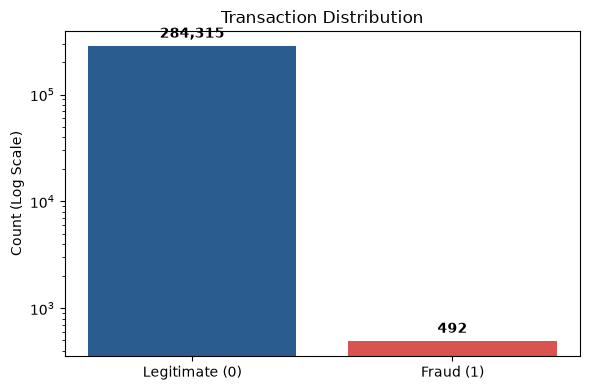

In [3]:
# Force inline non-interactive backend (prevents VS Code UI hangs)
import matplotlib
matplotlib.use('inline')
import matplotlib.pyplot as plt
import seaborn as sns

# Instant aggregated plot
counts = df_cleaned['Class'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(['Legitimate (0)', 'Fraud (1)'], counts.values, color=['#2b5c8f', '#d9534f'])
plt.title('Transaction Distribution')
plt.yscale('log')
plt.ylabel('Count (Log Scale)')

for i, count in enumerate(counts.values):
    plt.text(i, count * 1.2, f"{count:,}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

ImportError: cannot import name 'AveragePrecisionScore' from 'sklearn.metrics' (c:\Users\Hp\Desktop\fraud-detection-pipeline\.venv\Lib\site-packages\sklearn\metrics\__init__.py)

In [5]:
# Cell 3: Supervised Machine Learning Model (Random Forest)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, average_precision_score

# 1. Separate Features (X) and Target (y)
X = df_cleaned.drop('Class', axis=1)
y = df_cleaned['Class']

# 2. Stratified Train-Test Split (preserves exact fraud ratio in both sets)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Train Random Forest with Class Weighting
rf_model = RandomForestClassifier(n_estimators=50, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 4. Predict & Evaluate
y_pred = rf_model.predict(X_test)
y_probs = rf_model.predict_proba(X_test)[:, 1]

print("--- Model Classification Report ---")
print(classification_report(y_test, y_pred, digits=4))

# Compute Precision-Recall AUC (The gold standard metric for imbalanced data)
pr_auc = average_precision_score(y_test, y_probs)
print(f"PR-AUC Score: {pr_auc:.4f}")

--- Model Classification Report ---
              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998     56864
           1     0.9070    0.7959    0.8478        98

    accuracy                         0.9995     56962
   macro avg     0.9533    0.8979    0.9238     56962
weighted avg     0.9995    0.9995    0.9995     56962

PR-AUC Score: 0.8453


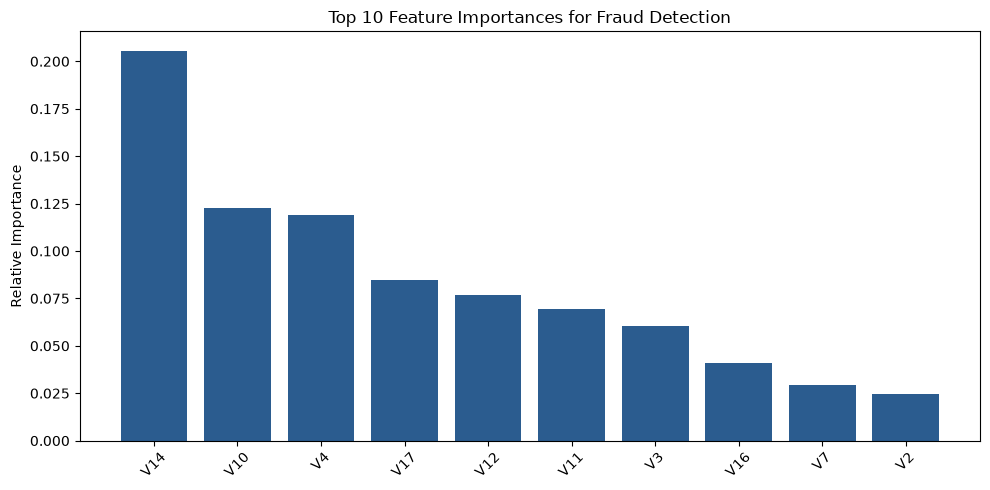

Top 5 Predictive Features:
1. V14: 0.2056
2. V10: 0.1226
3. V4: 0.1190
4. V17: 0.0846
5. V12: 0.0769


In [6]:
# Cell 4: Feature Importance Analysis
import numpy as np

# Extract feature importances from trained Random Forest
importances = rf_model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1][:10] # Top 10 features

# Plot Top 10 Features
plt.figure(figsize=(10, 5))
plt.title("Top 10 Feature Importances for Fraud Detection")
plt.bar(range(10), importances[indices], color='#2b5c8f', align="center")
plt.xticks(range(10), [feature_names[i] for i in indices], rotation=45)
plt.ylabel("Relative Importance")
plt.tight_layout()
plt.show()

# Print top 5 drivers
print("Top 5 Predictive Features:")
for i in range(5):
    print(f"{i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

In [7]:
import joblib
import os

os.makedirs('models', exist_ok=True)

# Save model and scaler
joblib.dump(rf_model, 'models/fraud_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

print("Model and scaler saved successfully in models/")

Model and scaler saved successfully in models/
